Elaborado por Paul Goyes
goyes.yesid@gmail.com

En el marco del proyecto 8091 (CTO-045-205)

In [23]:
import numpy as np
import matplotlib.pyplot as plt

import math
import cmath
import time
from scipy import constants
#start = time.clock();
# Please check the Magnetic Permeability (H/m)
# at: https://docs.scipy.org/doc/scipy-0.14.0/reference/constants.html#module-scipy.constants
mu = constants.mu_0; #Magnetic Permeability (H/m)

# forward modelling operator F[m] = d

def MTforwardModel(resistivities,thicknesses,frequencies):
  n = len(resistivities);
  apparentResistivity=[]
  Zxy=[]
  for frequency in frequencies:
      w =  2*math.pi*frequency;
      impedances = list(range(n));
      #compute basement impedance
      impedances[n-1] = np.sqrt(w*mu*resistivities[n-1]*1j);

      for j in range(n-2,-1,-1):
          resistivity = resistivities[j];
          thickness = thicknesses[j];

          # 3. Compute apparent resistivity from top layer impedance
          # Step 2. Iterate from bottom layer to top(not the basement)
          # Step 2.1 Calculate the intrinsic impedance of current layer
          dj = np.sqrt((w * mu * (1.0/resistivity))*1j);
          wj = dj * resistivity;
          # Step 2.2 Calculate Exponential factor from intrinsic impedance
          ej = np.exp(-2*thickness*dj);

          # Step 2.3 Calculate reflection coeficient using current layer
          #          intrinsic impedance and the below layer impedance
          belowImpedance = impedances[j + 1];
          rj = (wj - belowImpedance)/(wj + belowImpedance);
          re = rj*ej;
          Zj = wj * ((1 - re)/(1 + re));
          impedances[j] = Zj;

      # Step 3. Compute apparent resistivity from top layer impedance
      Z = impedances[0];
      #absZ = abs(Z);
      #apparentResistivity.append((absZ * absZ)/(mu * w))
      #phase.append(math.atan2(Z.imag, Z.real))
      Zxy.append(Z)
  return np.array(Zxy)

In [24]:
def drawModel1D(ax, thickness=None, values=None, model=None, depths=None,
                plot='plot',
                xlabel=r'Resistivity $(\Omega$m$)$', zlabel='Depth (m)',
                z0=0,
                **kwargs):
    """Draw 1d block model into axis ax.

    Draw 1d block model into axis ax defined by values and thickness vectors
    using plot function.
    For log y cases, z0 should be set > 0 so that the default becomes 1.

    Parameters
    ----------
    ax : mpl axes
        Matplotlib Axes object to plot into.

    values : iterable [float]
        [N] Values for each layer plus lower background.

    thickness : iterable [float]
        [N-1] thickness for each layer. Either thickness or depths must be set.

    depths : iterable [float]
        [N-1] Values for layer depths (positive z-coordinates).
        Either thickness or depths must be set.

    model : iterable [float]
        Shortcut to use default model definition.
        thks = model[0:nLay]
        values = model[nLay:]

    plot : string
        Matplotlib plotting function.
        'plot', 'semilogx', 'semilogy', 'loglog'

    xlabel : str
        Label for x axis.

    ylabel : str
        Label for y axis.

    z0 : float
        Starting depth in m

    **kwargs : dict()
        Forwarded to the plot routine

    Examples
    --------
    >>> import matplotlib.pyplot as plt
    >>> import numpy as np
    >>> import pygimli as pg
    >>> # plt.style.use('ggplot')
    >>> thk = [1, 4, 4]
    >>> res = np.array([10., 5, 15, 50])
    >>> fig, ax = plt.subplots()
    >>> pg.viewer.mpl.drawModel1D(ax, values=res*5, depths=np.cumsum(thk),
    ...                          plot='semilogx', color='blue')
    >>> pg.viewer.mpl.drawModel1D(ax, values=res, thickness=thk, z0=1,
    ...                          plot='semilogx', color='red')
    >>> pg.wait()
    """
    if model is not None:
        nLayers = (len(model)-1)//2
        thickness = model[:nLayers]
        values = model[nLayers:]

    if thickness is None and depths is None:
        raise Exception("Either thickness or depths must be given.")

    nLayers = len(values)
    px = np.zeros(nLayers * 2)
    pz = np.zeros(nLayers * 2)

    if thickness is not None:
        z1 = np.cumsum(thickness) + z0
    else:
        z1 = depths

    for i in range(nLayers):
        px[2 * i] = values[i]
        px[2 * i + 1] = values[i]

        if i == nLayers - 1:
            pz[2 * i + 1] = z1[i - 1] * 1.2
        else:
            pz[2 * i + 1] = z1[i]
            pz[2 * i + 2] = z1[i]

    if plot == 'loglog' or plot == 'semilogy':
        if z0 == 0:
            pz[0] = z1[0] / 2.
        else:
            pz[0] = z0

    try:
        plot = getattr(ax, plot)
        plot(px, pz+z0, **kwargs)
    except BaseException as e:
        print(e)

    ax.set_ylabel(zlabel)
    ax.set_xlabel(xlabel)
    # assume positive depths pointing upward
    ax.set_ylim(pz[-1], pz[0])
    ax.grid(True)

In [25]:
def randomModel(n=10,depthmax=20000,res=(0,3)):
  #created by Paul Goyes / goyes.yesid@gmail.com
  indx_rho = np.random.choice(200,n,replace=True)
  # # in Ohm-meter np.abs(np.random.normal(loc=1,scale=2,size=10))/3
  res = np.random.uniform(res[0], res[1], 200)
  resistivities = res[indx_rho];

  dz =   depthmax // (n-1)
  z = np.arange(n)*dz
  thicknesses = np.diff(z)
  return (10**resistivities,thicknesses)

[2500 2500 2500 2500]


(1, 1000)

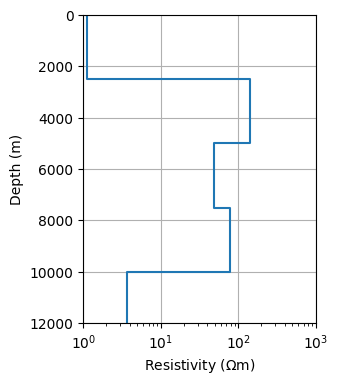

In [26]:
synres,synthk = randomModel(n=5,depthmax=10000)
print(synthk)
# plot resistivity model

fig, ax = plt.subplots(figsize=(3,4))
drawModel1D(ax, synthk, synres,plot='semilogx')
plt.xlim([1,10**3])

In [27]:
frequencies=np.logspace(-3, 3, 31) # In logarithmic equidistant range. (Hz)
Zxy = MTforwardModel(synres,synthk,frequencies)

In [28]:
print(np.c_[Zxy,frequencies])

[[1.30650090e-04+0.00011456j 1.00000000e-03+0.j        ]
 [1.67214567e-04+0.00013626j 1.58489319e-03+0.j        ]
 [2.12185566e-04+0.00015706j 2.51188643e-03+0.j        ]
 [2.64121280e-04+0.00017421j 3.98107171e-03+0.j        ]
 [3.18796296e-04+0.00018638j 6.30957344e-03+0.j        ]
 [3.70338726e-04+0.00019635j 1.00000000e-02+0.j        ]
 [4.14491772e-04+0.00021233j 1.58489319e-02+0.j        ]
 [4.51764837e-04+0.0002468j  2.51188643e-02+0.j        ]
 [4.89029853e-04+0.00031447j 3.98107171e-02+0.j        ]
 [5.41287403e-04+0.00043039j 6.30957344e-02+0.j        ]
 [6.34305116e-04+0.00060431j 1.00000000e-01+0.j        ]
 [7.98806863e-04+0.00082763j 1.58489319e-01+0.j        ]
 [1.04180141e-03+0.00107308j 2.51188643e-01+0.j        ]
 [1.33623302e-03+0.00134131j 3.98107171e-01+0.j        ]
 [1.68080380e-03+0.00167788j 6.30957344e-01+0.j        ]
 [2.11296551e-03+0.0021129j  1.00000000e+00+0.j        ]
 [2.66039998e-03+0.00266045j 1.58489319e+00+0.j        ]
 [3.34924854e-03+0.00334925j 2.

<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_12131/1454918640.py:4: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("$|\mathbf{Z}(\omega)|$", fontsize=12)


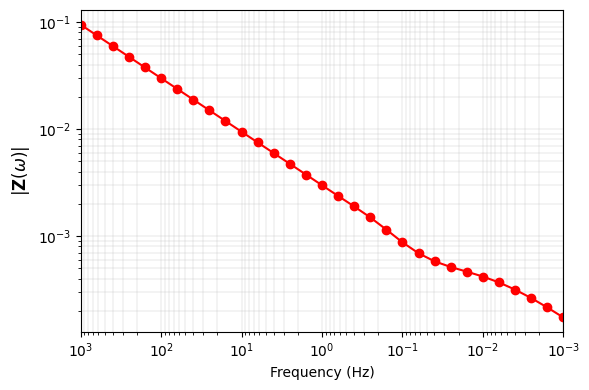

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.loglog(frequencies,np.abs(Zxy),'r-o'),
ax.set_ylabel("$|\mathbf{Z}(\omega)|$", fontsize=12)

ax.grid(True, which='both', linewidth=0.2)
ax.set_xlim(frequencies.max(), frequencies.min())
ax.set_xlabel("Frequency (Hz)", fontsize=10)

plt.tight_layout()
plt.show()